In [1]:
# Basic Imports
import numpy as np
import torch
from pydrake.geometry import Box as DrakeBox
from pydrake.geometry import Sphere as DrakeSphere
from dair_pll.geometry import (
    PydrakeToCollisionGeometryFactory,
    Polygon,
    Box,
    GeometryRepresentation,
    GeometryCollider,
)
from dair_pll.experiment_utils import chamfer_distance
from dair_pll.quaternion import quaternion_to_rotmat_vec

In [2]:
## Create Baseline Geometries
drake_sphere = DrakeSphere(0.1)
drake_box = DrakeBox(1., 1., 1.) # centered at model origin
dair_sphere = PydrakeToCollisionGeometryFactory.convert(drake_sphere, GeometryRepresentation.PRIMITIVE, learnable=False)
dair_box = PydrakeToCollisionGeometryFactory.convert(drake_box, GeometryRepresentation.PRIMITIVE, learnable=True)
dair_polygon = PydrakeToCollisionGeometryFactory.convert(drake_box, GeometryRepresentation.POLYGON, learnable=True)
# Box and polygon should have the same vertices
assert torch.all(torch.isclose(torch.sort(dair_box.get_vertices().detach(), dim=0)[0], torch.sort(dair_polygon.get_vertices().detach(), dim=0)[0]))

# And small Chamfer distance
sample_count = 10000
cdist = chamfer_distance(dair_box.sample_surface(sample_count), dair_polygon.sample_surface(sample_count))
print(f"Chamfer Dist: {cdist}")

Chamfer Dist: 0.02432956818634002


In [12]:
# Pose Parameters
polygon_a = dair_polygon
sphere_b = dair_sphere
quat_AB = torch.nn.Parameter(torch.tensor([1., 0., 0., 0.]), requires_grad=True)
R_AB = quaternion_to_rotmat_vec(quat_AB).reshape((3, 3))
p_AoBo_A = torch.nn.Parameter(torch.tensor([0., 0.9, 0.]))
p_AoBo_B = p_AoBo_A @ R_AB

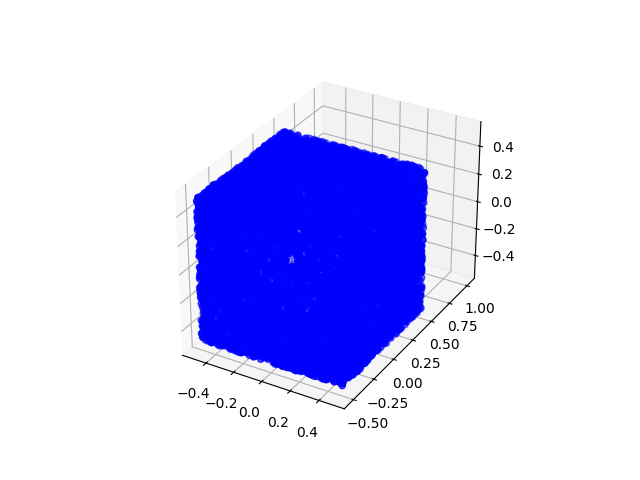

In [13]:
# Basic Plotting
%matplotlib widget
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
sphere_data = sphere_b.sample_surface(sample_count) + p_AoBo_B.detach().cpu().numpy()
polygon_data = polygon_a.sample_surface(sample_count)
# Plot the surfaces
ax.scatter(sphere_data[:, 0], sphere_data[:, 1], sphere_data[:, 2], color="green")
ax.scatter(polygon_data[:, 0], polygon_data[:, 1], polygon_data[:, 2], color="blue")

# Set an equal aspect ratio
ax.set_aspect('equal')

In [14]:
phi, R_AC, p_AoAc_A, p_BoBc_B = GeometryCollider.collide(dair_polygon, dair_sphere, R_AB, p_AoBo_A)

In [15]:
print(f"Contact Normal (polygon -> sphere in polygon frame): {R_AC[..., 2]}")
print(f"Contact Distance: {phi}")

Contact Normal (polygon -> sphere in polygon frame): tensor([[-0.0000e+00,  1.0000e+00, -1.3021e-09]], grad_fn=<SelectBackward0>)
Contact Distance: tensor([0.3000], grad_fn=<UnsqueezeBackward0>)


In [16]:
torch.autograd.grad(phi, list(dair_polygon.parameters()) + [p_AoBo_A, quat_AB], retain_graph=True, allow_unused=True)

(tensor([[ 0.0000e+00, -2.5000e-01,  3.2553e-10],
         [ 0.0000e+00, -2.5000e-01,  3.2553e-10],
         [ 0.0000e+00,  3.1962e-10, -6.7819e-19],
         [ 0.0000e+00,  3.1962e-10, -6.7819e-19],
         [ 0.0000e+00, -2.5000e-01,  3.2553e-10],
         [ 0.0000e+00, -2.5000e-01,  3.2553e-10],
         [ 0.0000e+00,  3.1962e-10, -6.7819e-19],
         [ 0.0000e+00,  3.1962e-10, -6.7819e-19]]),
 tensor([ 0.0000e+00,  1.0000e+00, -1.3021e-09]),
 tensor([0., 0., 0., 0.]))

In [19]:
p_AoAc_A

tensor([[-1.0000e-01,  6.5105e-11,  6.5105e-11]], grad_fn=<UnsqueezeBackward0>)

In [17]:
contact

tensor(0.8660, grad_fn=<MaxBackward1>)